# Pandas, NumPy, and Data Visualization Exercises

## Level

Intermediate

## Scenario

You are analyzing orders from an international e-commerce company. The file
`ecommerce_orders.csv` contains order data from 2024 and 2025.

The dataset contains a few realistic problems such as missing values, duplicate
rows, invalid values, and unusually large prices.

This version focuses on practical skills and avoids highly advanced topics such
as cohort analysis, bootstrap simulation, and complex customer segmentation.

## Main Skills

- Reading and inspecting data
- Simple missing-value handling
- Filtering and sorting
- Creating calculated columns
- GroupBy and Pivot Table
- Basic time-series analysis
- NumPy conditions
- Matplotlib and Pandas charts


## Setup

Keep `ecommerce_orders.csv` in the same folder as the notebook and run the cell
below before answering the questions.


In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

DATA_PATH = Path("ecommerce_orders.csv")
assert DATA_PATH.exists(), "Place ecommerce_orders.csv next to this notebook."

df_raw = pd.read_csv(DATA_PATH)

print("Dataset shape:", df_raw.shape)
df_raw.head()


Dataset shape: (6024, 21)


,order_id,order_date,ship_date,customer_id,customer_segment,country,city,channel,device,campaign,category,subcategory,product_id,unit_price,unit_cost,quantity,discount_pct,shipping_cost,payment_method,returned,satisfaction_score
0,ORD-002245,2025-04-30,2025-05-05,C00472,Consumer,Iran,Isfahan,Marketplace,Mobile,Search Ads,Home,Decor,HOM-DEC-003,139.31,122.59,1,0.07,7.98,Card,False,4.00
1,ORD-002874,2024-04-28,2024-05-02,C00637,Small Business,Iran,Shiraz,Website,Mobile,Organic,Sports,Fitness,SPO-FIT-134,57.08,35.77,2,0.01,15.13,Bank Transfer,False,4.00
2,ORD-003673,2024-03-29,2024-04-05,C00742,Consumer,Iran,Shiraz,Mobile App,iOS,Search Ads,Beauty,Makeup,BEA-MAK-046,112.00,68.36,1,0.27,11.41,Bank Transfer,False,3.00
3,ORD-000817,2024-04-23,2024-04-28,C00493,Small Business,Iran,Tehran,Website,Desktop,Email,Books,Fiction,BOO-FIC-104,10.14,7.21,8,0.09,14.43,Card,False,5.00
4,ORD-005651,2024-03-08,2024-03-09,C01240,Consumer,Iran,Tehran,Mobile App,Android,Organic,Beauty,Fragrance,BEA-FRA-003,11.21,7.78,1,0.02,6.03,Bank Transfer,False,5.00


## Data Dictionary

| Column | Description |
|---|---|
| `order_id` | Order identifier |
| `order_date` | Date of the order |
| `ship_date` | Shipping date |
| `customer_id` | Customer identifier |
| `customer_segment` | Customer type |
| `country`, `city` | Customer location |
| `channel`, `device` | Purchase channel and device |
| `campaign` | Marketing source |
| `category`, `subcategory` | Product category and subcategory |
| `unit_price`, `unit_cost` | Selling price and cost per unit |
| `quantity` | Number of items |
| `discount_pct` | Discount as a decimal value |
| `shipping_cost` | Shipping cost |
| `returned` | Whether the order was returned |
| `satisfaction_score` | Satisfaction score from 1 to 5 |


## Question 1 — Explore the Dataset

Display:

- The first 10 rows
- The number of rows and columns
- Column names
- Data types
- A basic statistical summary for numerical columns

Write one short comment about what you notice.

In [2]:
print(df_raw.shape)
print(df_raw.columns.tolist())
print(df_raw.dtypes)
df_raw.describe()


(6024, 21)
['order_id', 'order_date', 'ship_date', 'customer_id', 'customer_segment', 'country', 'city', 'channel', 'device', 'campaign', 'category', 'subcategory', 'product_id', 'unit_price', 'unit_cost', 'quantity', 'discount_pct', 'shipping_cost', 'payment_method', 'returned', 'satisfaction_score']
order_id                  str
order_date                str
ship_date                 str
customer_id               str
customer_segment          str
country                   str
city                      str
channel                   str
device                    str
campaign                  str
category                  str
subcategory               str
product_id                str
unit_price            float64
unit_cost             float64
quantity                int64
discount_pct          float64
shipping_cost         float64
payment_method            str
returned                 bool
satisfaction_score    float64
dtype: object


,unit_price,unit_cost,quantity,discount_pct,shipping_cost,satisfaction_score
count,"6,024.00","6,024.00","6,024.00","5,969.00","6,024.00","5,879.00"
mean,443.91,293.39,2.35,0.10,11.52,4.23
std,550.53,320.31,1.96,0.08,4.35,0.68
min,6.31,3.23,-1.00,-0.10,4.96,1.00
25%,80.78,53.51,1.00,0.04,8.38,4.00
50%,258.56,171.62,2.00,0.08,10.86,4.00
75%,583.82,389.24,3.00,0.14,13.53,5.00
max,"15,898.09","1,523.88",10.00,1.20,37.10,5.00


## Question 2 — Find Missing Values and Duplicates

Create a table showing the number and percentage of missing values in
each column.

Also calculate:

- The number of exact duplicate rows
- The number of duplicated `order_id` values

Do not clean the data yet.

In [3]:
missing_count = df_raw.isnull().sum()
missing_pct = (missing_count / len(df_raw)) * 100
missing_table = pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
missing_table = missing_table[missing_table['missing_count'] > 0]
print(missing_table)

print('Exact duplicate rows:', df_raw.duplicated().sum())
print('Duplicated order_id values:', df_raw['order_id'].duplicated().sum())


                    missing_count  missing_pct
city                           95         1.58
campaign                      120         1.99
discount_pct                   55         0.91
satisfaction_score            145         2.41
Exact duplicate rows: 24
Duplicated order_id values: 24


## Question 3 — Simple Missing-Value Handling

Create a copy named `df` and apply these simple rules:

- Fill missing `city` values with `"Unknown"`.
- Fill missing `campaign` values with `"Unknown"`.
- Fill missing `discount_pct` values with `0`.
- Fill missing `satisfaction_score` values with the overall median score.

Finally, verify that these four columns no longer contain missing values.

In [4]:
df = df_raw.copy()

df['city'] = df['city'].fillna('Unknown')
df['campaign'] = df['campaign'].fillna('Unknown')
df['discount_pct'] = df['discount_pct'].fillna(0)
df['satisfaction_score'] = df['satisfaction_score'].fillna(df['satisfaction_score'].median())

df[['city', 'campaign', 'discount_pct', 'satisfaction_score']].isnull().sum()


city                  0
campaign              0
discount_pct          0
satisfaction_score    0
dtype: int64

## Question 4 — Convert Dates and Remove Bad Rows

Perform the following cleaning steps:

1. Convert `order_date` and `ship_date` to datetime.
2. Remove exact duplicate rows.
3. Keep only rows where:
   - `quantity` is greater than zero.
   - `discount_pct` is between 0 and 1.
   - `ship_date` is equal to or later than `order_date`.

Display the number of rows before and after cleaning.

In [5]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

rows_before = len(df)
df = df.drop_duplicates()

df = df[
    (df['quantity'] > 0) &
    (df['discount_pct'] >= 0) & (df['discount_pct'] <= 1) &
    (df['ship_date'] >= df['order_date'])
]
rows_after = len(df)
print('before:', rows_before, 'after:', rows_after)


before: 6024 after: 5970


## Question 5 — Create New Columns

Create these columns:

- `delivery_days`
- `gross_sales = unit_price × quantity`
- `net_sales = gross_sales × (1 - discount_pct)`
- `total_cost = unit_cost × quantity + shipping_cost`
- `profit = net_sales - total_cost`
- `order_month`

Display five rows containing the new columns.

In [6]:
df['delivery_days'] = (df['ship_date'] - df['order_date']).dt.days
df['gross_sales'] = df['unit_price'] * df['quantity']
df['net_sales'] = df['gross_sales'] * (1 - df['discount_pct'])
df['total_cost'] = df['unit_cost'] * df['quantity'] + df['shipping_cost']
df['profit'] = df['net_sales'] - df['total_cost']
df['order_month'] = df['order_date'].dt.to_period('M')

df[['delivery_days', 'gross_sales', 'net_sales', 'total_cost', 'profit', 'order_month']].head()


,delivery_days,gross_sales,net_sales,total_cost,profit,order_month
0,5,139.31,129.28,130.57,-1.29,2025-04
1,4,114.16,113.45,86.67,26.78,2024-04
2,7,112.00,81.88,79.77,2.11,2024-03
3,5,81.12,73.47,72.11,1.36,2024-04
4,1,11.21,10.99,13.81,-2.82,2024-03


## Question 6 — Use NumPy Conditions

Create a new column named `sales_level` using `np.select`:

- `"Low"` for `net_sales` below 100
- `"Medium"` for `net_sales` from 100 to below 500
- `"High"` for `net_sales` from 500 to below 1000
- `"Very High"` for `net_sales` of 1000 or more

Display the number of orders in each sales level.

In [7]:
conditions = [
    df['net_sales'] < 100,
    (df['net_sales'] >= 100) & (df['net_sales'] < 500),
    (df['net_sales'] >= 500) & (df['net_sales'] < 1000),
    df['net_sales'] >= 1000
]

choices = ['Low', 'Medium', 'High', 'Very High']

df['sales_level'] = np.select(conditions, choices, default='Unknown')

df['sales_level'].value_counts()


sales_level
Medium       2179
Very High    1599
Low          1222
High          970
Name: count, dtype: int64

## Question 7 — Filter and Sort Orders

Find orders that meet all of these conditions:

- Category is `Electronics`
- Net sales are greater than 500
- The order was not returned

Sort the result by `net_sales` from highest to lowest and display the first 15
rows.

In [8]:
result = df[
    (df['category'] == 'Electronics') &
    (df['net_sales'] > 500) &
    (df['returned'] == False)
]

result = result.sort_values('net_sales', ascending=False)
result.head(15)


,order_id,order_date,ship_date,customer_id,customer_segment,country,city,channel,device,campaign,category,subcategory,product_id,unit_price,unit_cost,quantity,discount_pct,shipping_cost,payment_method,returned,satisfaction_score,delivery_days,gross_sales,net_sales,total_cost,profit,order_month,sales_level
2604,ORD-002283,2024-11-25,2024-11-29,C01003,Small Business,Turkey,Istanbul,Website,Tablet,Organic,Electronics,Headphones,ELE-HEA-102,"15,898.09","1,025.11",6,0.16,18.00,Wallet,False,5.00,4,"95,388.54","79,754.36","6,168.66","73,585.70",2024-11,Very High
2010,ORD-000241,2025-09-09,2025-09-15,C00066,Consumer,Iran,Shiraz,Website,Desktop,Organic,Electronics,Headphones,ELE-HEA-087,"1,582.87","1,199.66",10,0.00,17.12,Cash on Delivery,False,4.00,6,"15,828.70","15,828.70","12,013.72","3,814.98",2025-09,Very High
2118,ORD-005399,2025-02-04,2025-02-08,C00356,Consumer,UAE,Abu Dhabi,Website,Tablet,Affiliate,Electronics,Mobile,ELE-MOB-147,"1,654.23","1,205.85",10,0.04,28.92,Cash on Delivery,False,3.00,4,"16,542.30","15,797.90","12,087.42","3,710.48",2025-02,Very High
2354,ORD-001886,2024-06-22,2024-06-27,C00392,Consumer,Iran,Shiraz,Website,Tablet,Affiliate,Electronics,Laptop,ELE-LAP-118,"1,647.89",830.60,10,0.04,17.61,Wallet,False,5.00,5,"16,478.90","15,750.53","8,323.61","7,426.92",2024-06,Very High
5252,ORD-003051,2024-09-10,2024-09-16,C01769,Small Business,Iran,Tehran,Mobile App,iOS,Affiliate,Electronics,Monitor,ELE-MON-006,"1,698.76","1,336.01",10,0.08,28.16,Cash on Delivery,False,4.00,6,"16,987.60","15,575.93","13,388.26","2,187.67",2024-09,Very High
1538,ORD-000989,2024-03-30,2024-04-07,C00532,Consumer,Iran,Tehran,Mobile App,Android,Organic,Electronics,Mobile,ELE-MOB-040,"1,669.21","1,067.94",10,0.07,22.44,Card,False,4.00,8,"16,692.10","15,496.95","10,701.84","4,795.11",2024-03,Very High
2519,ORD-002363,2024-09-16,2024-09-17,C01225,Small Business,Iran,Mashhad,Website,Mobile,Search Ads,Electronics,Headphones,ELE-HEA-079,"15,802.53",893.73,1,0.05,6.14,Card,False,3.00,1,"15,802.53","14,939.71",899.87,"14,039.84",2024-09,Very High
2011,ORD-003648,2024-07-22,2024-07-27,C00488,Consumer,Iran,Mashhad,Mobile App,iOS,Organic,Electronics,Headphones,ELE-HEA-024,"1,724.92","1,286.50",10,0.16,26.19,Wallet,False,4.00,5,"17,249.20","14,496.23","12,891.19","1,605.04",2024-07,Very High
1977,ORD-002478,2024-11-19,2024-11-26,C01376,Small Business,Iran,Shiraz,Website,Mobile,Search Ads,Electronics,Monitor,ELE-MON-101,"1,521.07","1,023.63",10,0.06,21.79,Wallet,False,4.00,7,"15,210.70","14,354.34","10,258.09","4,096.25",2024-11,Very High
2131,ORD-001120,2024-09-14,2024-09-20,C00871,Consumer,Iran,Mashhad,Mobile App,Android,Search Ads,Electronics,Monitor,ELE-MON-146,"1,460.17",842.90,10,0.02,13.32,Wallet,False,4.00,6,"14,601.70","14,344.71","8,442.32","5,902.39",2024-09,Very High


## Question 8 — Category Summary

Create a summary by `category` containing:

- Number of orders
- Total net sales
- Average net sales
- Total profit
- Average satisfaction score

Sort categories by total net sales from highest to lowest.

In [9]:
category_summary = df.groupby('category').agg(
    order_count=('order_id', 'count'),
    total_net_sales=('net_sales', 'sum'),
    avg_net_sales=('net_sales', 'mean'),
    total_profit=('profit', 'sum'),
    avg_satisfaction=('satisfaction_score', 'mean')
)

category_summary = category_summary.sort_values('total_net_sales', ascending=False)
category_summary


,order_count,total_net_sales,avg_net_sales,total_profit,avg_satisfaction
category,,,,,
Electronics,1842,"3,879,321.68","2,106.04","1,064,535.85",4.18
Home,1302,"945,414.20",726.12,"229,555.57",4.24
Sports,958,"565,856.93",590.66,"144,255.70",4.27
Beauty,886,"185,635.34",209.52,"40,524.61",4.19
Books,982,"99,743.18",101.57,"14,433.54",4.25


## Question 9 — Country and Channel Summary

Create a grouped summary for each `country` and `channel` containing:

- Number of orders
- Total net sales
- Average delivery days
- Return rate as a percentage

Display the 15 groups with the highest total net sales.

In [10]:
country_channel_summary = df.groupby(['country', 'channel']).agg(
    order_count=('order_id', 'count'),
    total_net_sales=('net_sales', 'sum'),
    avg_delivery_days=('delivery_days', 'mean'),
    return_rate_pct=('returned', 'mean')
)

country_channel_summary['return_rate_pct'] = country_channel_summary['return_rate_pct'] * 100

country_channel_summary = country_channel_summary.sort_values('total_net_sales', ascending=False)
country_channel_summary.head(15)


order_count  total_net_sales  avg_delivery_days  \
country channel                                                            
Iran    Website                 1352     1,266,070.23               3.96   
        Mobile App              1165     1,136,579.93               3.83   
        Marketplace              560       547,791.83               3.91   
Turkey  Website                  440       504,334.14               4.98   
UAE     Website                  333       315,563.22               3.52   
Turkey  Mobile App               365       313,235.77               4.87   
Iran    Social Commerce          289       274,536.76               3.92   
UAE     Mobile App               308       274,179.76               3.48   
Germany Website                  293       239,794.85               5.43   
        Mobile App               232       212,231.58               5.49   
Turkey  Marketplace              182       187,811.78               5.01   
UAE     Marketplace              116        91,040.79               3.39   
Germany Social Commerce           64        83,122.84               5.28   
        Marketplace              104        79,549.33               5.50   
Turkey  Social Commerce           94        77,834.16               5.05   

                         return_rate_pct  
country channel                           
Iran    Website                     5.18  
        Mobile App                  6.18  
        Marketplace                 7.50  
Turkey  Website                     6.82  
UAE     Website                     6.91  
Turkey  Mobile App                  7.12  
Iran    Social Commerce             5.54  
UAE     Mobile App                  3.57  
Germany Website                     4.78  
        Mobile App                  6.47  
Turkey  Marketplace                 7.69  
UAE     Marketplace                10.34  
Germany Social Commerce             3.12  
        Marketplace                 7.69  
Turkey  Social Commerce             3.19

## Question 10 — Create a Pivot Table

Create a Pivot Table where:

- Rows are `category`
- Columns are `channel`
- Values are total `net_sales`

Fill missing values with zero and add a `Total` column for each category.

In [11]:
pivot = df.pivot_table(
    index='category',
    columns='channel',
    values='net_sales',
    aggfunc='sum',
    fill_value=0
)

pivot['Total'] = pivot.sum(axis=1)
pivot


channel,Marketplace,Mobile App,Social Commerce,Website,Total
category,,,,,
Beauty,"30,378.81","74,902.48","16,082.76","64,271.30","185,635.34"
Books,"17,820.28","35,564.65","6,420.23","39,938.03","99,743.18"
Electronics,"656,100.43","1,289,538.31","347,175.26","1,586,507.67","3,879,321.68"
Home,"129,373.95","334,558.50","85,983.92","395,497.82","945,414.20"
Sports,"72,520.27","201,663.10","52,125.95","239,547.62","565,856.93"


## Question 11 — Monthly Sales Trend

Calculate total `net_sales` for each month.

Then:

- Sort the result by month
- Calculate month-over-month percentage change
- Display the last 12 months
- Plot monthly net sales as a line chart

In [12]:
monthly_sales = df.groupby('order_month')['net_sales'].sum().sort_index()
monthly_pct_change = monthly_sales.pct_change() * 100

print(monthly_pct_change.tail(12))
monthly_sales.tail(12)


order_month
2025-01    23.02
2025-02   -27.48
2025-03    32.83
2025-04    16.66
2025-05   -21.80
2025-06   -20.79
2025-07    30.20
2025-08    10.24
2025-09     3.42
2025-10    -7.00
2025-11   -24.48
2025-12    13.38
Freq: M, Name: net_sales, dtype: float64


order_month
2025-01   257,412.92
2025-02   186,679.36
2025-03   247,959.12
2025-04   289,269.49
2025-05   226,218.57
2025-06   179,189.96
2025-07   233,300.24
2025-08   257,182.77
2025-09   265,972.20
2025-10   247,352.24
2025-11   186,808.40
2025-12   211,796.52
Freq: M, Name: net_sales, dtype: float64

customer_summary = df.groupby('customer_id').agg(
    order_count=('order_id', 'nunique'),
    total_net_sales=('net_sales', 'sum'),
    total_profit=('profit', 'sum'),
    avg_satisfaction=('satisfaction_score', 'mean')
)

customer_summary = customer_summary.sort_values('total_net_sales', ascending=False)
customer_summary.head(10)


## Question 13 — Return Analysis

Calculate the return rate for each `category`.

Then create a bar chart showing the return rate percentage by category.

Which category has the highest return rate?

category
Electronics   8.85
Beauty        7.11
Home          5.30
Sports        4.70
Books         2.04
Name: returned, dtype: float64


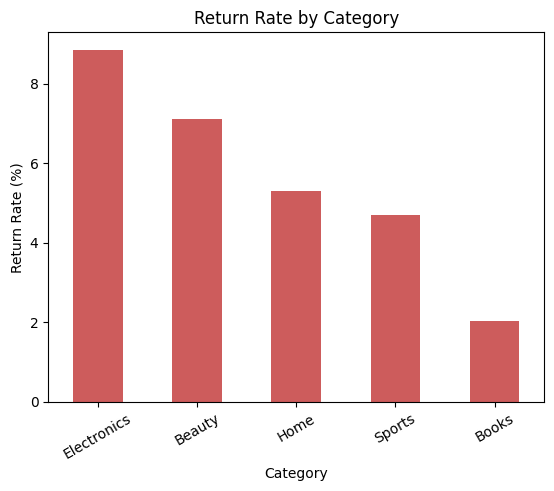

Electronics has the highest return rate.


In [13]:
return_rate = df.groupby('category')['returned'].mean() * 100
return_rate = return_rate.sort_values(ascending=False)
print(return_rate)

return_rate.plot(kind='bar', color='indianred')
plt.xlabel('Category')
plt.ylabel('Return Rate (%)')
plt.title('Return Rate by Category')
plt.xticks(rotation=30)
plt.show()

print("Electronics has the highest return rate.")


## Question 14 — Simple Outlier Detection

Use the IQR method on the complete `unit_price` column:

1. Calculate Q1, Q3, and IQR.
2. Define the lower and upper limits.
3. Create a DataFrame named `price_outliers`.
4. Display the number of outliers and the 10 highest outlier prices.

Do not calculate separate limits for each category.

In [14]:
Q1 = df['unit_price'].quantile(0.25)
Q3 = df['unit_price'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

price_outliers = df[(df['unit_price'] < lower_limit) | (df['unit_price'] > upper_limit)]

print('Number of outliers:', len(price_outliers))
price_outliers.sort_values('unit_price', ascending=False)['unit_price'].head(10)


Number of outliers: 530


2604   15,898.09
2519   15,802.53
4289    3,668.80
4207    2,552.92
3827    1,834.78
2810    1,799.39
74      1,799.16
1795    1,799.13
2066    1,799.12
1892    1,798.36
Name: unit_price, dtype: float64

## Question 15 — Final Visualization

Create a 2×2 figure containing:

1. Total net sales by category
2. Total profit by channel
3. Monthly net sales trend
4. Average satisfaction score by country

Add titles and axis labels. Below the code, write three short observations based
on the charts.

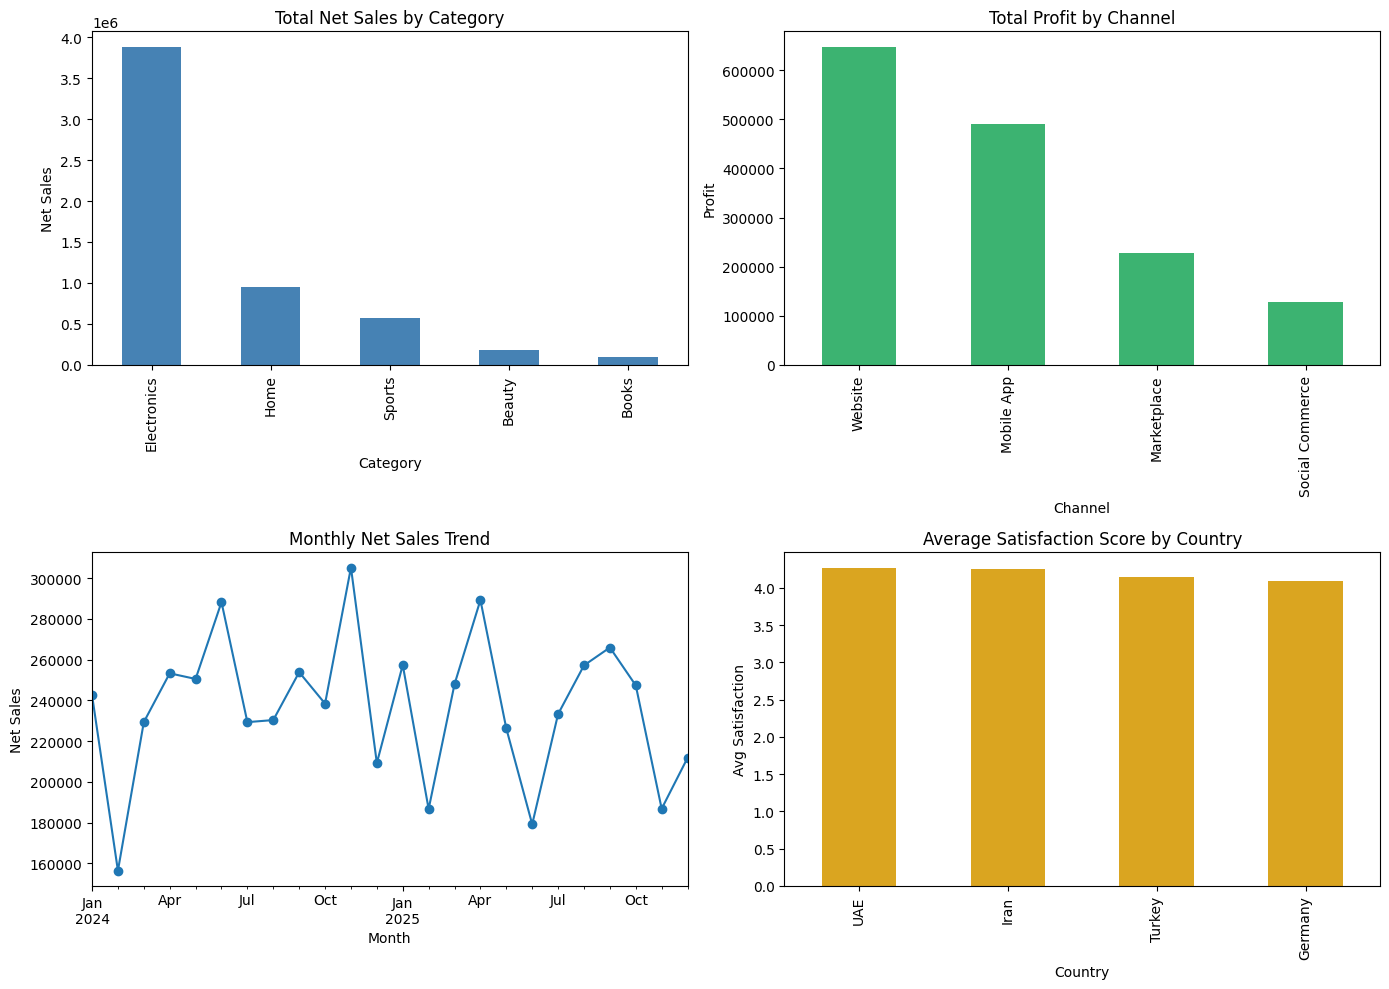


Observations:
1. Electronics generates by far the most net sales of any category.
2. Website is the most profitable channel, Social Commerce the least.
3. Average satisfaction is fairly similar across countries (4.0-4.25),
   unlike sales which are far more unequal across countries.



In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df.groupby('category')['net_sales'].sum().sort_values(ascending=False).plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Total Net Sales by Category')
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Net Sales')

df.groupby('channel')['profit'].sum().sort_values(ascending=False).plot(kind='bar', ax=axes[0,1], color='mediumseagreen')
axes[0,1].set_title('Total Profit by Channel')
axes[0,1].set_xlabel('Channel')
axes[0,1].set_ylabel('Profit')

df.groupby('order_month')['net_sales'].sum().sort_index().plot(kind='line', marker='o', ax=axes[1,0])
axes[1,0].set_title('Monthly Net Sales Trend')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Net Sales')

df.groupby('country')['satisfaction_score'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[1,1], color='goldenrod')
axes[1,1].set_title('Average Satisfaction Score by Country')
axes[1,1].set_xlabel('Country')
axes[1,1].set_ylabel('Avg Satisfaction')

plt.tight_layout()
plt.show()

print('''
Observations:
1. Electronics generates by far the most net sales of any category.
2. Website is the most profitable channel, Social Commerce the least.
3. Average satisfaction is fairly similar across countries (4.0-4.25),
   unlike sales which are far more unequal across countries.
''')


## Final Check

Restart the kernel and run all cells before submitting your work. Make sure every
chart has a title and readable axis labels.
